In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [4]:
# ─── ──────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualization ───────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Pipelines Scikit-Learn ────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ─── 4.Preprocessing ───────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

# ─── 5. Validation ───────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

# ─── 6. warnings ───────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

#───Settings ───────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

print("The professional setup is available and the workshop is fully equipped!")

The professional setup is available and the workshop is fully equipped!


In [5]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

X = train.drop(columns=['Id', 'SalePrice'])
y = np.log1p(train['SalePrice'])

X_test = test.drop(columns=['Id'])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Target (log1p SalePrice) - mean: {y.mean():.3f}, std: {y.std():.3f}")

Train shape: (1460, 81)
Test shape: (1459, 80)
Target (log1p SalePrice) - mean: 12.024, std: 0.399


In [6]:
X.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [7]:
X.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


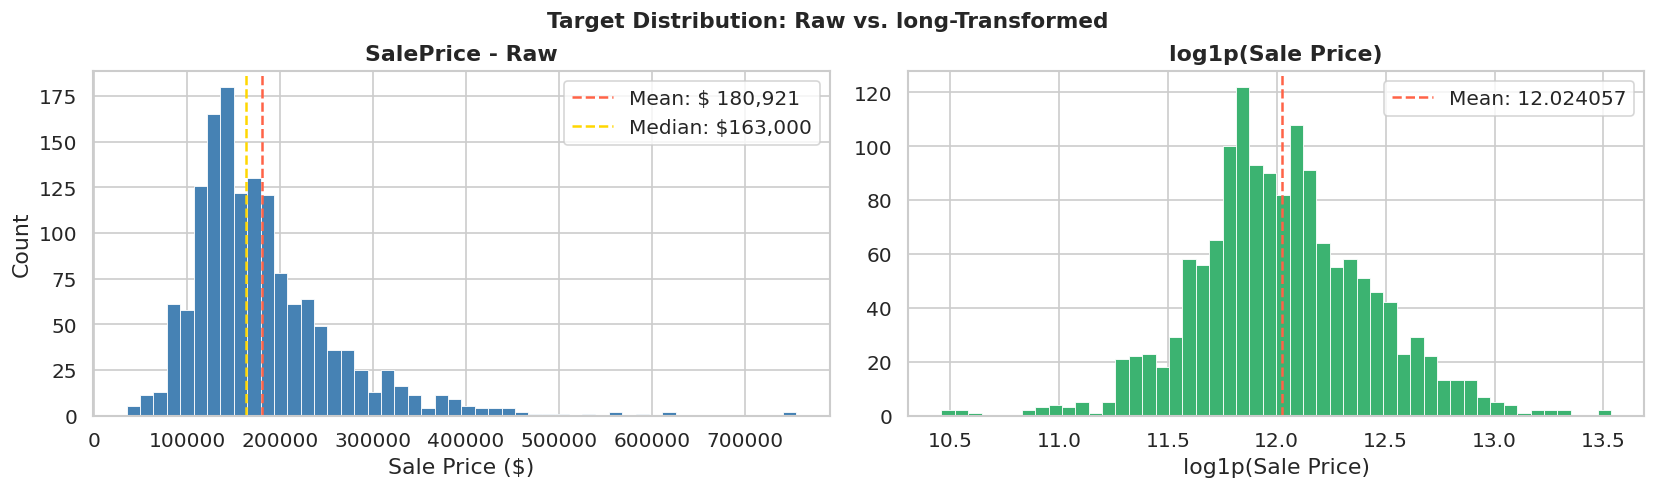

Skewness: 1.880941
Skewness (log1p): 0.121


In [8]:
from scipy .stats import skew

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
            train['SalePrice'],
            bins=50,
            color='steelblue',
            edgecolor='white',
            linewidth=0.5
)
axes[0].set_title('SalePrice - Raw', fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[0].axvline(
            train['SalePrice'].mean(),
            color='tomato',
            linestyle='--',
            label=f"Mean: $ {train['SalePrice'].mean():,.0f}"
)
axes[0].axvline(
            train['SalePrice'].median(),
            color='gold',
            linestyle='--',
            label=f"Median: ${train['SalePrice'].median():,.0f}"
)
axes[0].legend()

# log raw
axes[1].hist(
             y, bins=50,
             color='mediumseagreen',
             edgecolor='white',
             linewidth=0.5
)

axes[1].set_title('log1p(Sale Price)', fontweight='bold' )
axes[1].set_xlabel('log1p(Sale Price)')

axes[1].axvline(
                y.mean(),
                color='tomato',
                linestyle='--', 
                label=f"Mean: {y.mean():3f}"
)

axes[1].legend()

plt.tight_layout()
plt.suptitle(
            'Target Distribution: Raw vs. long-Transformed',
             y=1.02,
             fontsize=13,
             fontweight='bold'
)
plt.show()

print(f"Skewness: {skew(train['SalePrice']):3f}")
print(f"Skewness (log1p): {skew(y):.3f}")

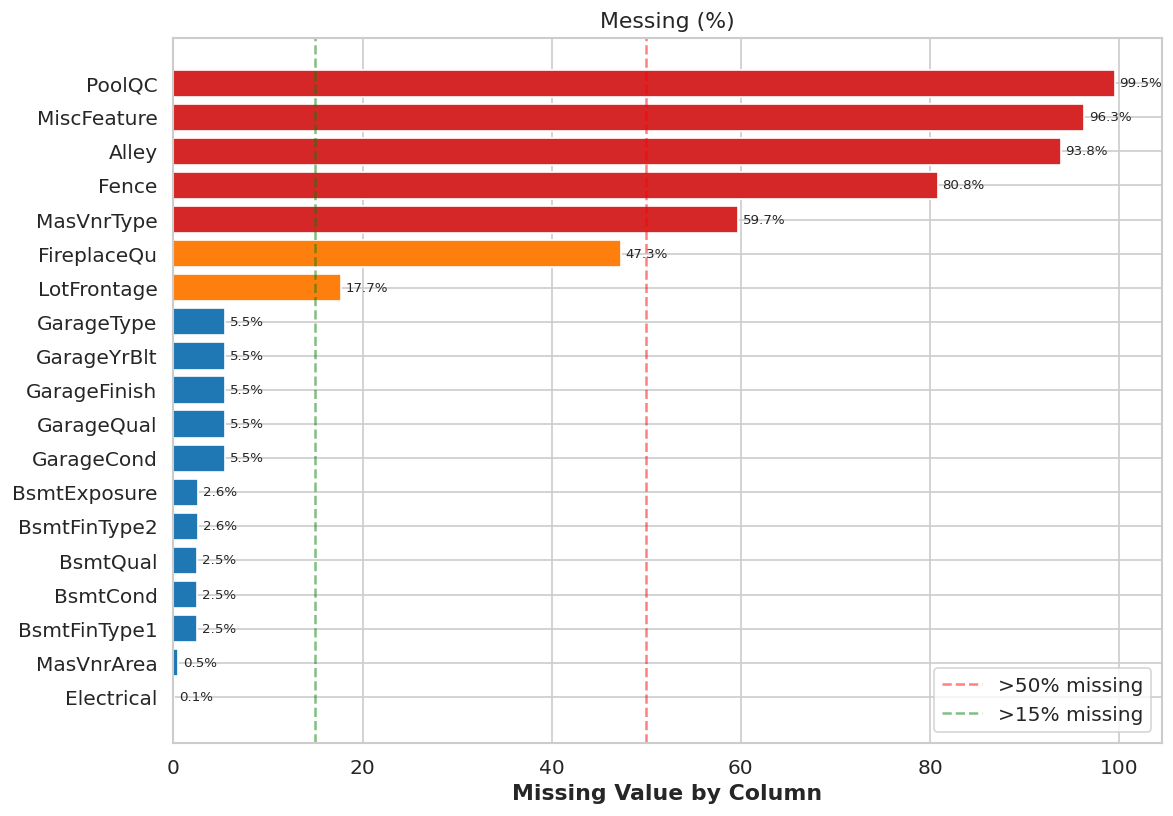

Total columns with missing value: 19
Columns > 80 missing (structural absence drop/Non-fill):
PoolQC         99.5
MiscFeature    96.3
Alley          93.8
Fence          80.8


In [9]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(10,7))
colors = ['#d62728' if p > 50 else '#ff7f0e' if p > 15 else '#1f77b4' for p in missing_pct]
bars = ax.barh(missing.index, missing_pct, color=colors)

ax.set_title('Messing (%)')
ax.set_xlabel('Missing Value by Column', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='>50% missing')
ax.axvline(15, color='green', linestyle='--', alpha=0.5, label='>15% missing')

for bar, val in zip(bars, missing_pct):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{val}%", va='center', fontsize=8)
    
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total columns with missing value: {len(missing)}")
print(f"Columns > 80 missing (structural absence drop/Non-fill):")
print(missing_pct[missing_pct > 80].to_string())

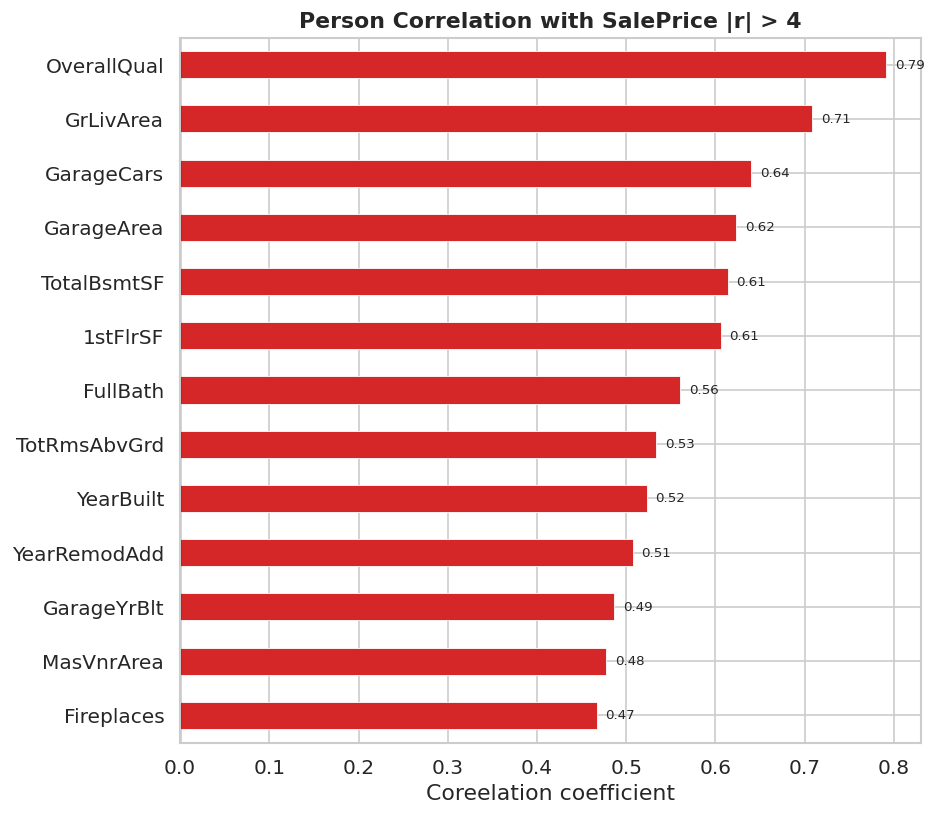

In [10]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_with_price = train[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values()
top_corr = corr_with_price[abs(corr_with_price) > 0.4]

fig, ax=plt.subplots(figsize=(8,7))
colors = ['#d62728' if c > 0 else '#1f77b8' for c in top_corr]
top_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Person Correlation with SalePrice |r| > 4', fontweight='bold')
ax.set_xlabel('Coreelation coefficient')

for i, (val, bar) in enumerate(zip(top_corr, ax.patches)):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2, 
    f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

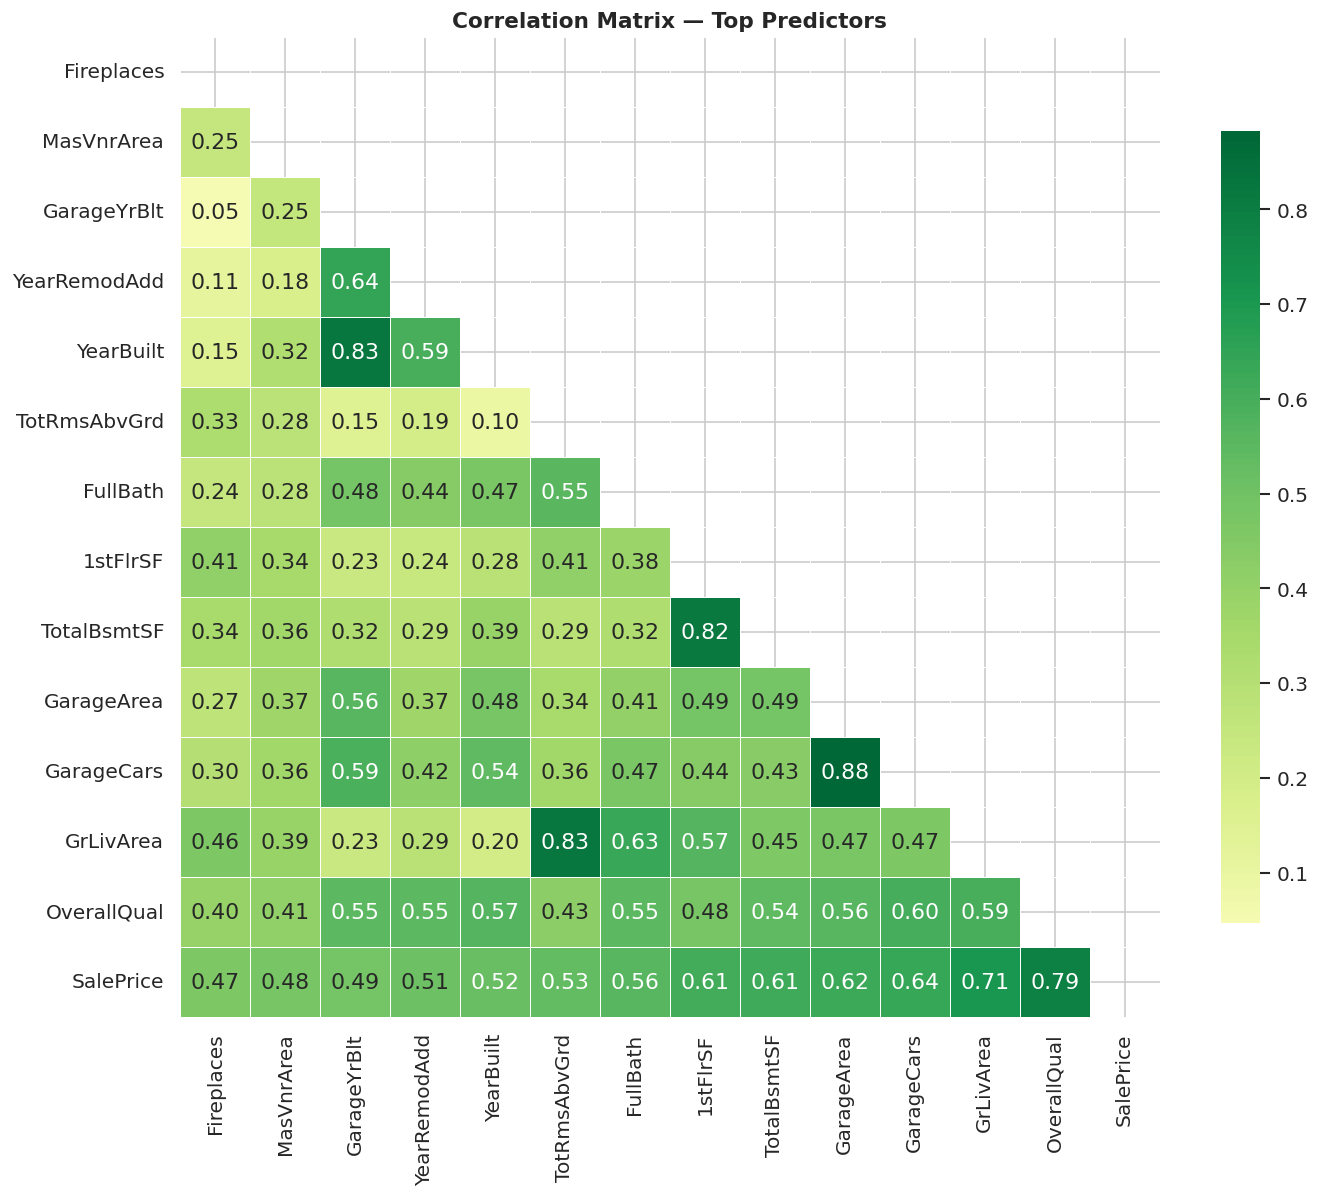

In [14]:
#Heatmap
top_features = top_corr.index.tolist() + ['SalePrice']
corr_matrix = train[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Top Predictors', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

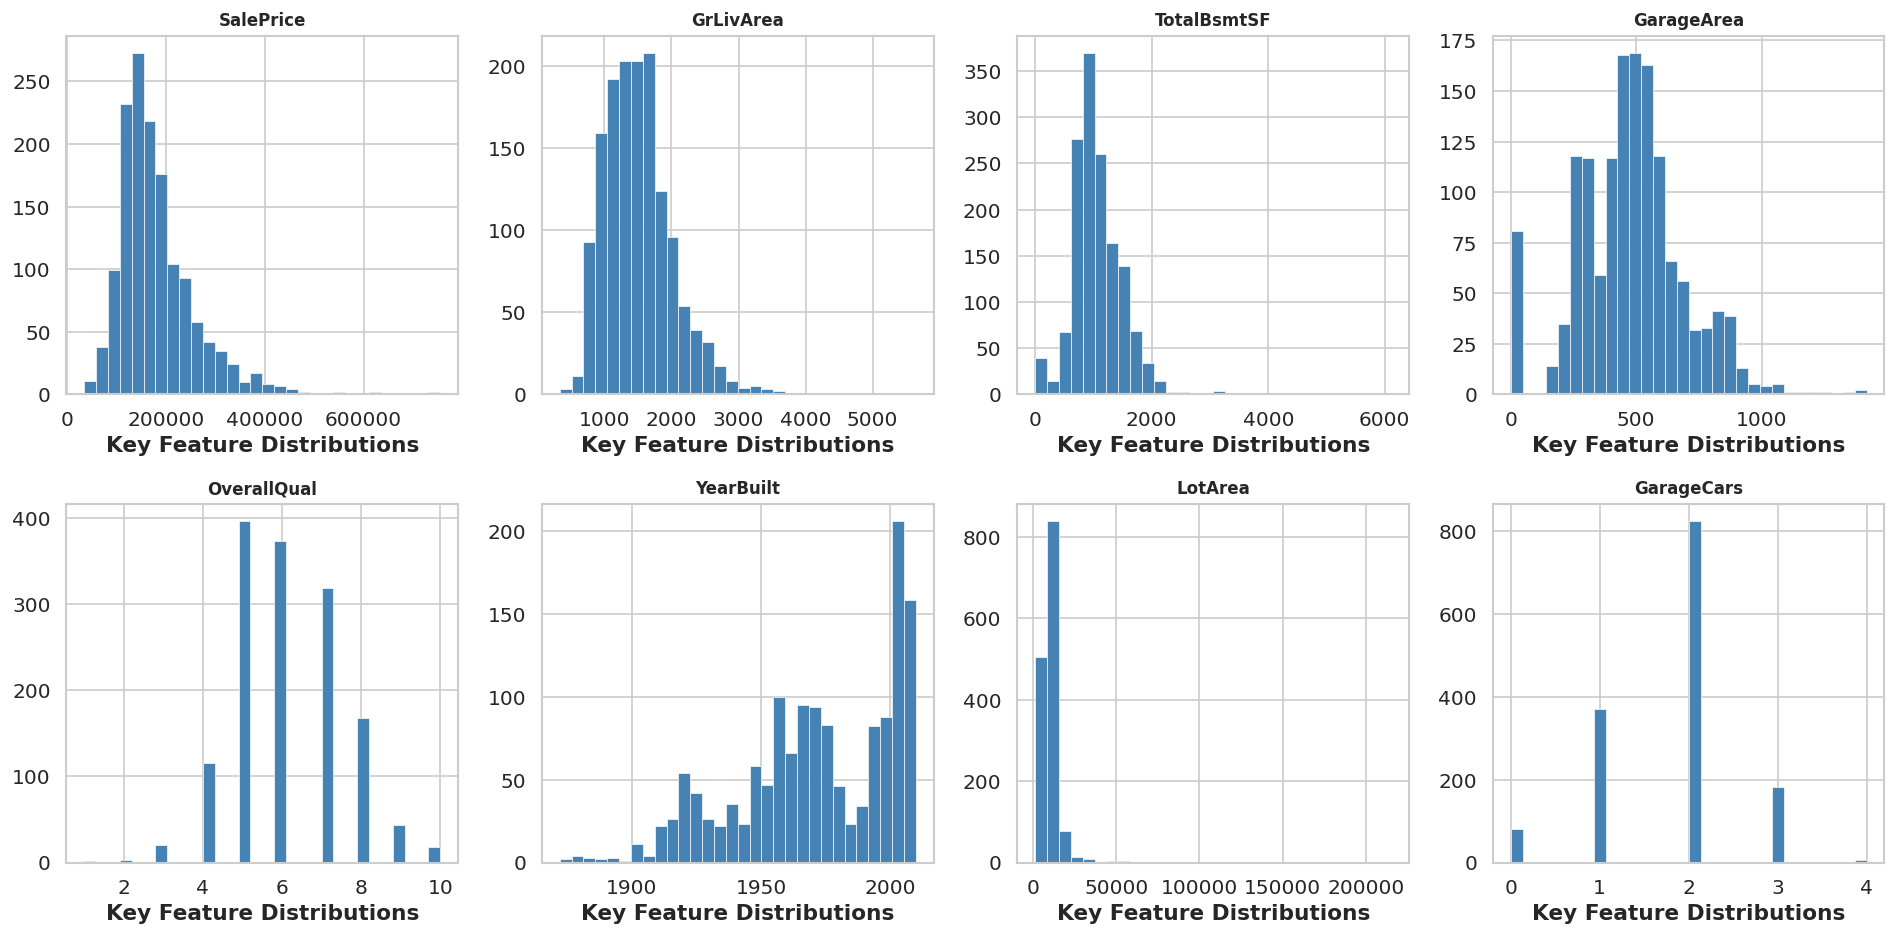

In [20]:
important_cols = [
    "SalePrice", "GrLivArea", "TotalBsmtSF", "GarageArea",
    "OverallQual", "YearBuilt", "LotArea", "GarageCars"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flatten(), important_cols):
    data = train[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    skewness = skew(data)
    ax.set_xlabel(f'Key Feature Distributions', fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()